## 📊 Data Analysis Project: Restaurant Tips EDA
Welcome to this beginner-friendly Data Analysis project! In this project, we will perform **Exploratory Data Analysis (EDA)** on a real-world dataset containing restaurant tipping information using Python's **Pandas**, **Seaborn**, and **Matplotlib** libraries.

### 🎯 Objectives of this Project:
1. **Load and Inspect Data**: Understand the dataset structure, column types, and check for missing values.
2. **Feature Engineering**: Add useful calculated columns (e.g., tip percentage).
3. **Analyze Trends & Relationships**:
   - How does total bill relate to tips?
   - Do males or females tip more on average?
   - Which days are busiest and yield higher tips?
   - Does party size influence tipping behavior?
4. **Summary & Insights**: Draw simple conclusions from our findings.

---
## Step 1: Import Required Libraries
First, we import the Python libraries needed for data manipulation and visualization.
- **Pandas**: Used for data loading, manipulation, and summary stats.
- **NumPy**: Used for numerical operations.
- **Seaborn & Matplotlib**: Used for creating visualizations and charts.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style for Seaborn plots
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


---
## Step 2: Load the Dataset
We load the built-in **`tips`** dataset provided by Seaborn. This dataset contains information on 244 restaurant bills, including total bill amount, tip amount, customer gender, smoking preference, day of the week, meal time, and party size.

In [2]:
# Load the 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

# Display the first 5 rows of the dataset
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


---
## Step 3: Inspect the Data & Check Health
Before analyzing data, we must inspect its shape, column types, summary statistics, and check for missing (null) values.

In [3]:
# Check total number of rows and columns (rows, columns)
print("Dataset Shape:", df.shape)

# Check data types and non-null counts for each column
df.info()

Dataset Shape: (244, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Check for missing/null values in any column
print("Missing values count per column:")
print(df.isnull().sum())

Missing values count per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [5]:
# Summary statistics for numerical columns (total_bill, tip, size)
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


---
## Step 4: Feature Engineering (Adding New Columns)
Feature engineering means creating new columns from existing data to get deeper insights. 
Here, we calculate **`tip_pct`** (tip percentage) = `(tip / total_bill) * 100`.

In [6]:
# Calculate Tip Percentage and round to 2 decimal places
df['tip_pct'] = round((df['tip'] / df['total_bill']) * 100, 2)

# Display the updated DataFrame with tip_pct column
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


---
## Step 5: Data Visualization & Exploratory Data Analysis (EDA)

Now we will create visualizations to explore relationships in our data.

### 5.1 Distribution of Total Bill & Tip
Let's look at how bill amounts and tips are distributed.

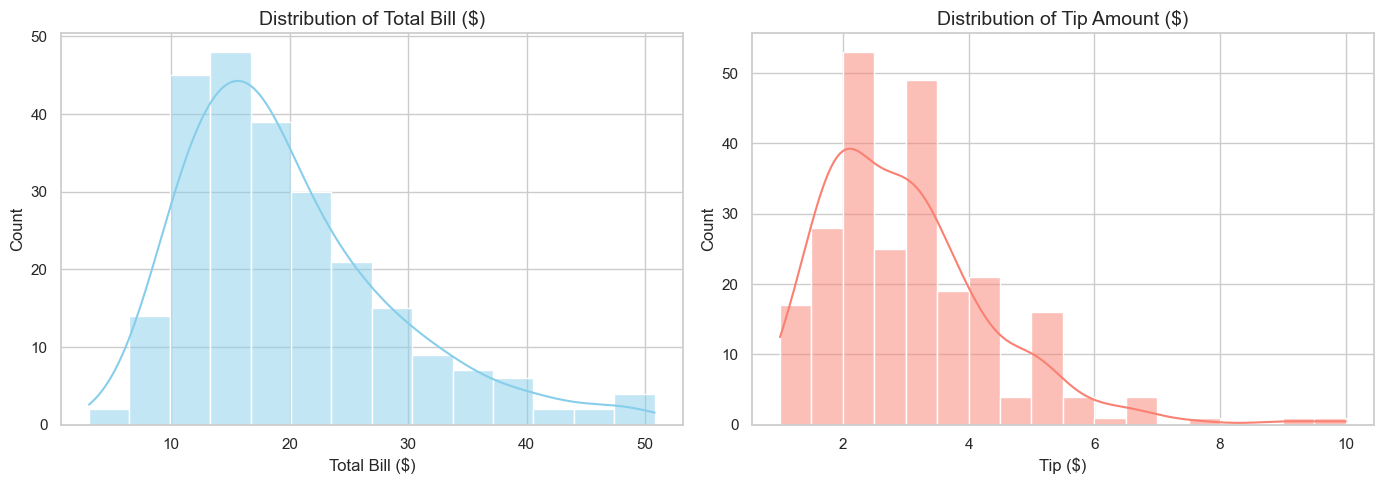

In [7]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Total Bill
sns.histplot(df['total_bill'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Total Bill ($)', fontsize=14)
axes[0].set_xlabel('Total Bill ($)')

# Plot 2: Distribution of Tip Amount
sns.histplot(df['tip'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Tip Amount ($)', fontsize=14)
axes[1].set_xlabel('Tip ($)')

plt.tight_layout()
plt.show()

### 5.2 Relationship Between Total Bill and Tip Amount
Do higher bills lead to higher tips? Let's check using a **Scatter Plot**.

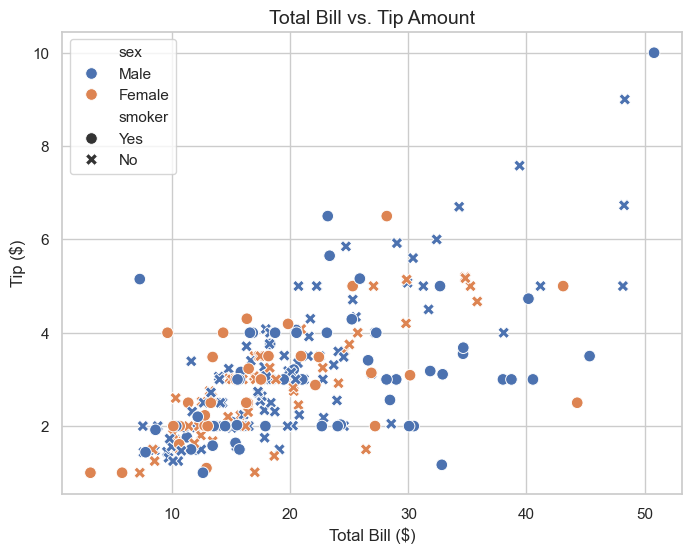

In [8]:
plt.figure(figsize=(8, 6))

# Scatter plot showing Total Bill vs Tip, colored by Gender
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', style='smoker', s=70)

plt.title('Total Bill vs. Tip Amount', fontsize=14)
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.show()

### 5.3 Average Tip by Gender & Smoker Status
Let's see who gives higher average tips: Males vs Females, and Smokers vs Non-Smokers.

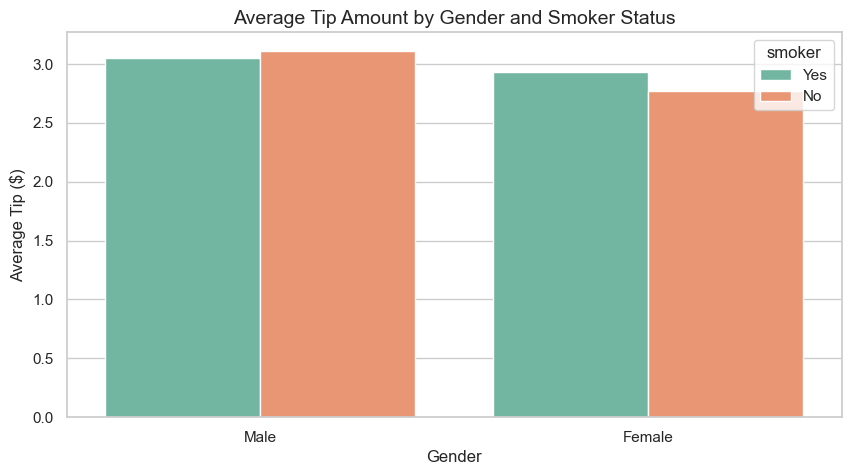

In [9]:
plt.figure(figsize=(10, 5))

# Bar plot comparing average tip by Gender and Smoker status
sns.barplot(data=df, x='sex', y='tip', hue='smoker', errorbar=None, palette='Set2')

plt.title('Average Tip Amount by Gender and Smoker Status', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Tip ($)', fontsize=12)
plt.show()

### 5.4 Total Bill Distribution Across Days of the Week
Which day brings in higher bill amounts? We use a **Box Plot** to compare.

C:\Users\DELL\AppData\Local\Temp\ipykernel_17816\2799155899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='total_bill', palette='Pastel1')


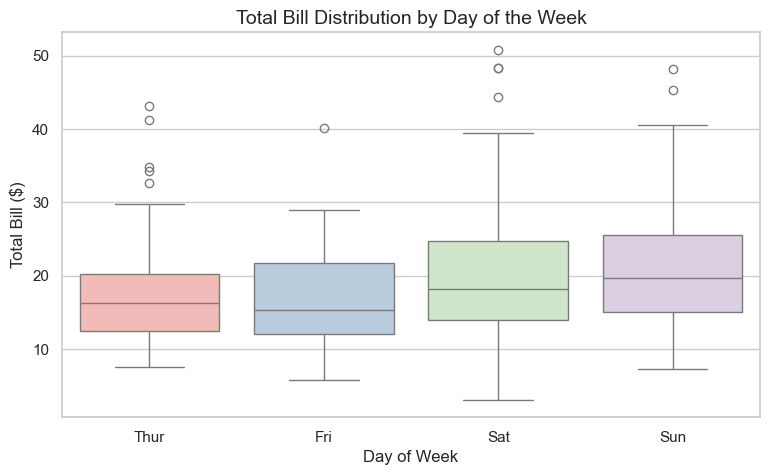

In [10]:
plt.figure(figsize=(9, 5))

# Box plot of Total Bill by Day
sns.boxplot(data=df, x='day', y='total_bill', palette='Pastel1')

plt.title('Total Bill Distribution by Day of the Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Bill ($)', fontsize=12)
plt.show()

### 5.5 Tip Percentage by Meal Time (Lunch vs Dinner)
Does tipping percentage differ between Lunch and Dinner time?

C:\Users\DELL\AppData\Local\Temp\ipykernel_17816\1718431595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='time', y='tip_pct', palette='coolwarm')


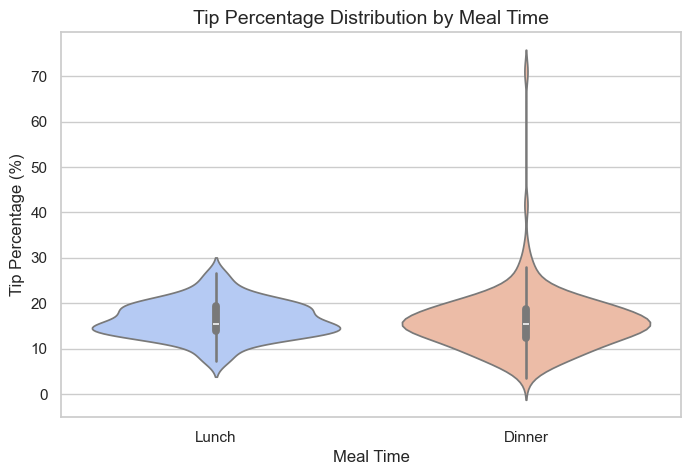

In [11]:
plt.figure(figsize=(8, 5))

# Violin plot comparing Tip Percentage between Lunch and Dinner
sns.violinplot(data=df, x='time', y='tip_pct', palette='coolwarm')

plt.title('Tip Percentage Distribution by Meal Time', fontsize=14)
plt.xlabel('Meal Time', fontsize=12)
plt.ylabel('Tip Percentage (%)', fontsize=12)
plt.show()

### 5.6 Correlation Matrix Heatmap
A correlation matrix helps us see numerical relationships between variables (-1 to +1 scale).

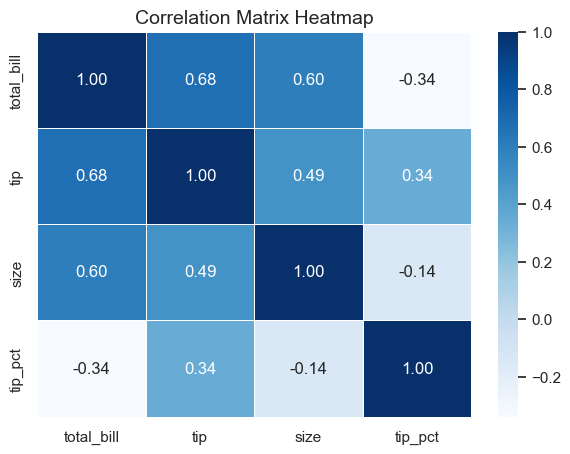

In [12]:
plt.figure(figsize=(7, 5))

# Select numerical columns for correlation calculation
numeric_cols = df[['total_bill', 'tip', 'size', 'tip_pct']]
corr_matrix = numeric_cols.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()

---
## Step 6: Summary & Key Insights 💡

Based on our exploratory data analysis of the restaurant tips dataset, here are the main conclusions:

1. **Positive Correlation**: There is a strong positive correlation between `total_bill` and `tip` amount—as the bill increases, the tip generally increases.
2. **Tip Percentage**: Most customers tip between **14% and 20%** of their total bill.
3. **Busiest Days**: Saturday and Sunday generate the highest total bill amounts compared to Thursday and Friday.
4. **Gender & Tipping**: On average, male and female tipping behaviors are fairly similar, with male groups showing slightly higher maximum bill amounts.
5. **Party Size**: Larger party sizes lead to higher total bills and total tips, but not necessarily a higher tip percentage per person.